In [2]:
import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.models.schnet import GaussianSmearing
from torch_geometric.loader import DataLoader
import numpy as np
from fairchem.core.datasets import AseDBDataset
import torch
from torch.nn import Linear
from torch_geometric.nn import SchNet
# from Torch_Helper import mol_to_data
from Mol_Properties_Extract import Extract_Mol_Properties
from torch_geometric.data import Data
import torch
from sklearn.model_selection import train_test_split
from torch_cluster import radius_graph



W0416 19:51:00.478000 24291 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
#Function to conver into PyTorch Geometric data
def mol_to_data(z, pos, y):
    z = torch.tensor(z, dtype=torch.long)
    pos = torch.tensor(pos, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)

    return Data(z=z, pos=pos, y=y)

In [4]:
dataset_path = "./train_4M/data0000.aselmdb"
dataset = AseDBDataset({"src": dataset_path})

In [5]:
N = len(dataset)
max_atoms = 500  # or whatever upper bound you choose

Z = np.zeros((N, max_atoms), dtype=np.int32)
pos = np.zeros((N, max_atoms, 3), dtype=np.float32)
mask = np.zeros((N, max_atoms), dtype=bool)
y = np.zeros(N, dtype=np.float32)

In [6]:
for i in range(len(dataset)):

    atoms = dataset.get_atoms(i)
    n = len(atoms)

    Z[i, :n] = atoms.get_atomic_numbers()
    pos[i, :n] = atoms.get_positions()
    mask[i, :n] = 1
    homo_lumo_gap = atoms.info["homo_lumo_gap"]
    if isinstance(homo_lumo_gap, (list, tuple, np.ndarray)):
        homo_lumo_gap = np.mean(homo_lumo_gap)

    y[i] = homo_lumo_gap

In [ ]:
print(pos[mask])
print(Z[mask])
Z[0][mask[0]]

In [8]:
torch_data = [mol_to_data(Z[i][mask[i]], pos[i][mask[i]], y[i]) for i in range(len(Z))]

In [9]:
#Split the Data
torch_data[2]

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32)

Data(y=7.031163692474365, pos=[41, 3], z=[41])

In [ ]:
Z[0]

In [11]:
from torch.utils.data import random_split

train_size = int(0.8 * len(torch_data))
val_size = len(torch_data) - train_size

train_dataset, val_dataset = random_split(torch_data, [train_size, val_size])

In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:


class SchNetModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.schnet = SchNet(
            hidden_channels=128,
            num_filters=128,
            num_interactions=6,
            num_gaussians=50,
            cutoff=10.0,
        )

        # self.lin = Linear(128, 1)

    def forward(self, data):
        out = self.schnet(data.z, data.pos, batch=data.batch)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SchNetModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        # print(data)
        data = data.to(device)

        optimizer.zero_grad()
        pred = model(data)
        loss = loss_fn(pred, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0

    for data in loader:
        data = data.to(device)
        pred = model(data)
        loss = loss_fn(pred, data.y)
        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
epochs = 50
train_losses = np.zeros(epochs)
val_losses = np.zeros(epochs)

for epoch in range(50):
    train_loss = train()
    val_loss = evaluate(val_loader)

    train_losses[epoch] = train_loss
    val_losses[epoch] = val_loss

    print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([28])) that is different to the input size (torch.Size([28, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/miniconda3/envs/277b-final/lib/python3.11/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([15])) that is different to the input size (torch.Size([15, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 001 | Train Loss: 48.6549 | Val Loss: 13.5002
Epoch 002 | Train Loss: 13.7766 | Val Loss: 11.0957
Epoch 003 | Train Loss: 11.9643 | Val Loss: 9.4777
Epoch 004 | Train Loss: 10.5182 | Val Loss: 8.6393
Epoch 005 | Train Loss: 9.6347 | Val Loss: 8.1654
Epoch 006 | Train Loss: 9.0291 | Val Loss: 9.2342
Epoch 007 | Train Loss: 8.8196 | Val Loss: 7.7786
Epoch 008 | Train Loss: 8.3619 | Val Loss: 8.9568
Epoch 009 | Train Loss: 8.1162 | Val Loss: 7.7985
Epoch 010 | Train Loss: 7.7597 | Val Loss: 7.3573
Epoch 011 | Train Loss: 7.6409 | Val Loss: 8.1372
Epoch 012 | Train Loss: 7.4522 | Val Loss: 7.1532
Epoch 013 | Train Loss: 7.1695 | Val Loss: 6.6627
Epoch 014 | Train Loss: 7.0418 | Val Loss: 6.5100
Epoch 015 | Train Loss: 6.8222 | Val Loss: 8.8978
Epoch 016 | Train Loss: 6.8808 | Val Loss: 8.6647
Epoch 017 | Train Loss: 6.6256 | Val Loss: 7.6629
Epoch 018 | Train Loss: 6.5083 | Val Loss: 6.4583
Epoch 019 | Train Loss: 6.4528 | Val Loss: 6.3731
Epoch 020 | Train Loss: 6.3946 | Val Loss: 6

In [ ]:
log_text = """
Epoch 001 | Train Loss: 48.6549 | Val Loss: 13.5002
Epoch 002 | Train Loss: 13.7766 | Val Loss: 11.0957
Epoch 003 | Train Loss: 11.9643 | Val Loss: 9.4777
Epoch 004 | Train Loss: 10.5182 | Val Loss: 8.6393
Epoch 005 | Train Loss: 9.6347 | Val Loss: 8.1654
Epoch 006 | Train Loss: 9.0291 | Val Loss: 9.2342
Epoch 007 | Train Loss: 8.8196 | Val Loss: 7.7786
Epoch 008 | Train Loss: 8.3619 | Val Loss: 8.9568
Epoch 009 | Train Loss: 8.1162 | Val Loss: 7.7985
Epoch 010 | Train Loss: 7.7597 | Val Loss: 7.3573
Epoch 011 | Train Loss: 7.6409 | Val Loss: 8.1372
Epoch 012 | Train Loss: 7.4522 | Val Loss: 7.1532
Epoch 013 | Train Loss: 7.1695 | Val Loss: 6.6627
Epoch 014 | Train Loss: 7.0418 | Val Loss: 6.5100
Epoch 015 | Train Loss: 6.8222 | Val Loss: 8.8978
Epoch 016 | Train Loss: 6.8808 | Val Loss: 8.6647
Epoch 017 | Train Loss: 6.6256 | Val Loss: 7.6629
Epoch 018 | Train Loss: 6.5083 | Val Loss: 6.4583
Epoch 019 | Train Loss: 6.4528 | Val Loss: 6.3731
Epoch 020 | Train Loss: 6.3946 | Val Loss: 6.2905
Epoch 021 | Train Loss: 6.1742 | Val Loss: 6.2740
Epoch 022 | Train Loss: 6.1479 | Val Loss: 6.0976
Epoch 023 | Train Loss: 6.0718 | Val Loss: 6.2484
Epoch 024 | Train Loss: 6.0494 | Val Loss: 5.9755
Epoch 025 | Train Loss: 5.9083 | Val Loss: 8.1054
Epoch 026 | Train Loss: 5.8993 | Val Loss: 5.9857
Epoch 027 | Train Loss: 5.7729 | Val Loss: 6.6143
Epoch 028 | Train Loss: 5.7462 | Val Loss: 6.2537
Epoch 029 | Train Loss: 5.7739 | Val Loss: 6.0596
Epoch 030 | Train Loss: 5.6538 | Val Loss: 6.0230
Epoch 031 | Train Loss: 5.5696 | Val Loss: 6.1039
Epoch 032 | Train Loss: 5.6190 | Val Loss: 6.1258
Epoch 033 | Train Loss: 5.4925 | Val Loss: 6.3156
Epoch 034 | Train Loss: 5.4177 | Val Loss: 6.5816
Epoch 035 | Train Loss: 5.4021 | Val Loss: 6.1650
Epoch 036 | Train Loss: 5.3685 | Val Loss: 5.9215
Epoch 037 | Train Loss: 5.2395 | Val Loss: 5.8842
Epoch 038 | Train Loss: 5.2766 | Val Loss: 5.9335
Epoch 039 | Train Loss: 5.2102 | Val Loss: 5.7925
Epoch 040 | Train Loss: 5.1876 | Val Loss: 5.8348
Epoch 041 | Train Loss: 5.1215 | Val Loss: 6.1020
Epoch 042 | Train Loss: 5.1080 | Val Loss: 6.2057
Epoch 043 | Train Loss: 5.0646 | Val Loss: 5.9158
Epoch 044 | Train Loss: 5.0230 | Val Loss: 6.0110
Epoch 045 | Train Loss: 4.9991 | Val Loss: 6.0188
Epoch 046 | Train Loss: 4.9251 | Val Loss: 6.0244
Epoch 047 | Train Loss: 4.9636 | Val Loss: 6.5076
Epoch 048 | Train Loss: 4.9097 | Val Loss: 5.8606
Epoch 049 | Train Loss: 4.8565 | Val Loss: 5.8860
Epoch 050 | Train Loss: 4.8157 | Val Loss: 6.6031
"""

In [37]:
import re

train_losses = np.zeros(50)
val_losses = np.zeros(50)

for i, line in enumerate(log_text.split("\n")):
    match = re.search(r"Train Loss: ([0-9.]+) \| Val Loss: ([0-9.]+)", line)
    if match:
        train_losses[i - 1] = float(match.group(1))
        val_losses[i - 1] = (float(match.group(2)))

print(train_losses)
print(val_losses)

[48.6549 13.7766 11.9643 10.5182  9.6347  9.0291  8.8196  8.3619  8.1162
  7.7597  7.6409  7.4522  7.1695  7.0418  6.8222  6.8808  6.6256  6.5083
  6.4528  6.3946  6.1742  6.1479  6.0718  6.0494  5.9083  5.8993  5.7729
  5.7462  5.7739  5.6538  5.5696  5.619   5.4925  5.4177  5.4021  5.3685
  5.2395  5.2766  5.2102  5.1876  5.1215  5.108   5.0646  5.023   4.9991
  4.9251  4.9636  4.9097  4.8565  4.8157]
[13.5002 11.0957  9.4777  8.6393  8.1654  9.2342  7.7786  8.9568  7.7985
  7.3573  8.1372  7.1532  6.6627  6.51    8.8978  8.6647  7.6629  6.4583
  6.3731  6.2905  6.274   6.0976  6.2484  5.9755  8.1054  5.9857  6.6143
  6.2537  6.0596  6.023   6.1039  6.1258  6.3156  6.5816  6.165   5.9215
  5.8842  5.9335  5.7925  5.8348  6.102   6.2057  5.9158  6.011   6.0188
  6.0244  6.5076  5.8606  5.886   6.6031]


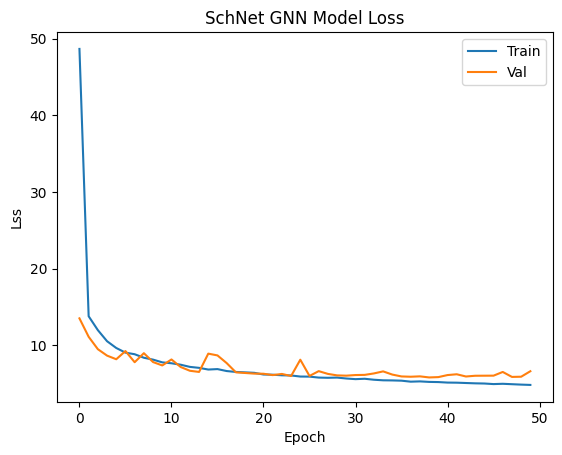

In [52]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.plot(val_losses)
plt.title("SchNet GNN Model Loss")
plt.ylabel('Lss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [39]:
test_dataset_path = "./train_4M/data0001.aselmdb"
test_dataset = AseDBDataset({"src": dataset_path})
print(len(test_dataset))

49835


In [46]:
N = 10000
max_atoms = 500  # or whatever upper bound you choose

Z_test = np.zeros((N, max_atoms), dtype=np.int32)
pos_test = np.zeros((N, max_atoms, 3), dtype=np.float32)
mask_test = np.zeros((N, max_atoms), dtype=bool)
y_test = np.zeros(N, dtype=np.float32)

In [47]:
for i in range(N):

    atoms = test_dataset.get_atoms(i)
    n = len(atoms)

    Z_test[i, :n] = atoms.get_atomic_numbers()
    pos_test[i, :n] = atoms.get_positions()
    mask_test[i, :n] = 1
    homo_lumo_gap = atoms.info["homo_lumo_gap"]
    if isinstance(homo_lumo_gap, (list, tuple, np.ndarray)):
        homo_lumo_gap = np.mean(homo_lumo_gap)

    y_test[i] = homo_lumo_gap

In [48]:
torch_data_test = [mol_to_data(Z_test[i][mask[i]], pos_test[i][mask[i]], y_test[i]) for i in range(len(Z_test))]

In [49]:
test_loader = DataLoader(torch_data_test, batch_size=32)

In [50]:
@torch.no_grad()
def test_model(loader):
    model.eval()

    total_mae = 0
    total_mse = 0
    total_samples = 0

    for data in loader:
        data = data.to(device)

        pred = model(data)
        target = data.y.view(-1, 1)

        mae = torch.abs(pred - target).sum()
        mse = ((pred - target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        total_samples += target.size(0)

    mean_mae = total_mae / total_samples
    rmse = (total_mse / total_samples) ** 0.5

    return mean_mae, rmse

In [51]:
mae, rmse = test_model(test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.9184
Test RMSE: 2.4576


### Future Improvements:

1. Scale data 
2. Try different loss function
3. Increase number of layers
4. Hypertune cutoff distance  
5. Train for more epochs